# Install the Pytorch

```python
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
```

In [1]:
import torch
print("Pytorch version:", torch.__version__)

Pytorch version: 2.11.0+cpu


Pytorch can automatically use a GPU if it's available.

In [2]:
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
  print("GPU Name: ", torch.cuda.get_device_name(0))
else:
  print("Running on CPU")

CUDA Available: False
Running on CPU


Create a tensor in Pytorch

In [3]:
# by default, pytorch tensors are immutable in nature
vector = torch.tensor([1, 2, 3, 4, 5])
print(vector)

tensor([1, 2, 3, 4, 5])


In [4]:
vector[2] = 30
print(vector)

tensor([ 1,  2, 30,  4,  5])


Create a tensor filled with 0's

In [5]:
zeros = torch.zeros((2, 3))
print(zeros)

tensor([[0., 0., 0.],
        [0., 0., 0.]])


Create a tensor filled with 1's

In [6]:
ones = torch.ones((2, 3))
print(ones)

tensor([[1., 1., 1.],
        [1., 1., 1.]])


Create a random tensors

In [7]:
random_tensors = torch.rand((2, 3))
print(random_tensors)

tensor([[0.1263, 0.9854, 0.2620],
        [0.8739, 0.4508, 0.8964]])


Tensor Operations

Arithmetic Operations

In [8]:
a = torch.tensor([2, 4, 6])
b = torch.tensor([1, 2, 3])

print(f'Addition: {a+b}')
print(f'Subtraction: {a-b}')
print(f'Multiplication: {a*b}')
print(f'Division: {a/b}')

Addition: tensor([3, 6, 9])
Subtraction: tensor([1, 2, 3])
Multiplication: tensor([ 2,  8, 18])
Division: tensor([2., 2., 2.])


Matrix Multiplication

In [9]:
a = torch.tensor([[1, 2],
                  [3, 4]])

b = torch.tensor([[5, 6],
                  [7, 8]])

print(torch.matmul(a, b))

tensor([[19, 22],
        [43, 50]])


In [10]:
tensor = torch.arange(12)
print(tensor)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


In [11]:
reshaped_tensor = tensor.reshape(3,4)
print(reshaped_tensor)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


In [12]:
reshaped_tensor = tensor.reshape(4,3)
print(reshaped_tensor)

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])


Automatic Differentiation

1. Forward Pass

In [13]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2 + 5 * x + 2
print(y)

tensor(26., grad_fn=<AddBackward0>)


2. Backward Pass

In [14]:
y.backward()
print("Gradient of y wrt x: ", x.grad)

Gradient of y wrt x:  tensor(11.)


Build Neural Network Architecture from scratch

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

Select Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
print(device)

cuda


Download the MNIST dataset

In [4]:
train_data = datasets.MNIST(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor()
)

test_data = datasets.MNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.83MB/s]


Create the dataloaders

In [5]:
batch_size = 64

train_loader = DataLoader(
    train_data,
    batch_size = batch_size,
    shuffle = True
)

test_loader = DataLoader(
    test_data,
    batch_size = batch_size,
    shuffle = False
)

Visualize the data

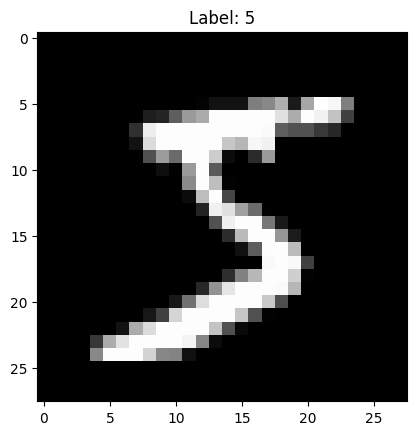

In [6]:
image, label = train_data[0]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f'Label: {label}')
plt.show()

Build the Neural Network

In [22]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.network = nn.Sequential(
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )


  def forward(self, x):
    x = self.flatten(x)
    return self.network(x)

Create the model

In [23]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


Loss Function and Optimizer

In [24]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001
)

Training Loop

In [25]:
epochs = 20

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward Pass
        predictions = model.forward(images)

        # Compute Loss
        loss = loss_function(predictions, labels)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    # Print after one complete epoch
    print(f"Epoch {epoch+1}/{epochs}, "
          f"Loss = {running_loss/len(train_loader):.4f}")

Epoch 1/20, Loss = 0.3443
Epoch 2/20, Loss = 0.1424
Epoch 3/20, Loss = 0.0966
Epoch 4/20, Loss = 0.0743
Epoch 5/20, Loss = 0.0570
Epoch 6/20, Loss = 0.0464
Epoch 7/20, Loss = 0.0368
Epoch 8/20, Loss = 0.0325
Epoch 9/20, Loss = 0.0265
Epoch 10/20, Loss = 0.0211
Epoch 11/20, Loss = 0.0200
Epoch 12/20, Loss = 0.0167
Epoch 13/20, Loss = 0.0133
Epoch 14/20, Loss = 0.0140
Epoch 15/20, Loss = 0.0140
Epoch 16/20, Loss = 0.0087
Epoch 17/20, Loss = 0.0113
Epoch 18/20, Loss = 0.0105
Epoch 19/20, Loss = 0.0082
Epoch 20/20, Loss = 0.0056


Model Prediction

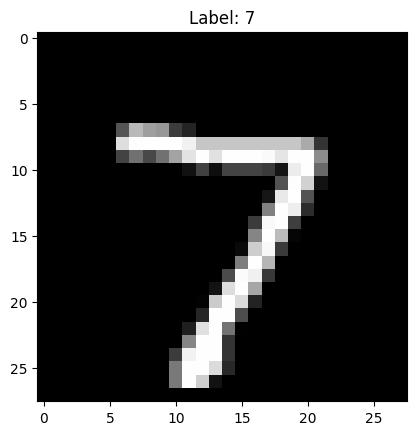

In [28]:
image, label = test_data[0]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f'Label: {label}')
plt.show()

In [27]:
model.eval()
with torch.no_grad():
  image = image.to(device)
  prediction = model(image.unsqueeze(0))
  predicted_class = prediction.argmax(dim=1).item()

print(predicted_class)
print(label)

7
7
